## Modeling the agent
1. Feature selection: remove the columns I will not use (for example, the indexing, lat, longitude, and name of the station)
2. Train the models with resampling
3. .....


### Libraries and tools to ues




### Preparation on google colab

!pip install -U ipython

In [ ]:
"""
%load_ext autoreload
%autoreload 2

#Clone the repository
import os
if not os.path.exists("your-project"):
    !git clone https://github.com/ras112git/predictive_modeling_and_mobility_forecasting.git
else:
    print("Repo already cloned.")


%cd predictive_modeling_and_mobility_forecasting

# Install dependencies
!pip install -r requirements.txt

import sys
sys.path.append(os.getcwd())
"""


### Preparation of the venvironment (as on the other notebooks)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

# Make src/ importable: add the project root (parent of notebooks/) to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Run from the project root so relative paths like "data/raw/..." resolve
os.chdir(project_root)
print(f"Working dir: {os.getcwd()}")


Working dir: c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting


### Automatically clean the data

In [2]:
from src.model import *

import pandas as pd

# Start by importing the data
train_path = Path('data/raw/dataset_train.csv')
df_train = pd.read_csv(train_path)

In [3]:
# I will clean it heare, as if I cleaned it and saved it as csv, then the categories will be missed

from src.data_cleaning import clean_data

df_train = clean_data(dataset= df_train, 
                      is_train = True, 
                      categorize_station = True) # If I put false here, it splits the station data in bolean

df_train

,id,datetime,station_number,name,lat,lng,bikes,hour,minute,dayofweek,...,hour_sin,hour_cos,is_holiday,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m
0,2024-09-03 17:30:00_32000,2024-09-03 17:30:00,32000,Julius-Raab-Platz,48.211544,16.382374,25,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
1,2024-09-03 17:30:00_32001,2024-09-03 17:30:00,32001,Hoher Markt,48.210666,16.372983,14,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
2,2024-09-03 17:30:00_32002,2024-09-03 17:30:00,32002,Oper,48.202683,16.369702,9,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
3,2024-09-03 17:30:00_32003,2024-09-03 17:30:00,32003,Volksgarten,48.206516,16.360400,3,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
4,2024-09-03 17:30:00_32004,2024-09-03 17:30:00,32004,Taborstraße U2,48.219522,16.382218,5,17,30,1,...,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150245,2025-03-13 08:00:00_32275,2025-03-13 08:00:00,32275,eLastenräder - Am langen Felde,48.250224,16.450650,0,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150246,2025-03-13 08:00:00_32277,2025-03-13 08:00:00,32277,eLastenräder - Bruno-Marek-Allee 6,48.227914,16.391516,6,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150247,2025-03-13 08:00:00_32278,2025-03-13 08:00:00,32278,eLastenräder - Am Tabor 23,48.224598,16.392090,3,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150248,2025-03-13 08:00:00_32280,2025-03-13 08:00:00,32280,ALF Mobility-Point,48.251355,16.452810,5,8,0,3,...,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88


### Feature selection

In [4]:
# Split the features

TARGET = "bikes"

x_train, y_train = data_split(df_train,target=TARGET)
#print(X_train)


In [5]:
#Make sure that the data is ordered by datetime
assert x_train['datetime'].is_monotonic_increasing

DROP_COLS = ["id", "datetime", "name"] #, "lat", "lng"

x_train = prepare_features(X = x_train, drop_cols=DROP_COLS)

In [5]:
featurce_performance = feature_selection_report(x_train,y_train)

print("features:", featurce_performance)
print("train data shape:", x_train.shape)


features: [0.53354889 0.53064709 0.532228   0.         0.         0.0017935
 0.00572979 0.00102152 0.         0.00111312 0.00094518 0.0088185
 0.00418775 0.         0.         0.00764668 0.00181072 0.        ]
train data shape: (2150250, 18)


In [6]:
x_train

,station_number,lat,lng,hour,minute,dayofweek,month,is_weekend,hour_sin,hour_cos,is_holiday,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m
0,32000,48.211544,16.382374,17,30,1,9,0,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
1,32001,48.210666,16.372983,17,30,1,9,0,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
2,32002,48.202683,16.369702,17,30,1,9,0,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
3,32003,48.206516,16.360400,17,30,1,9,0,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
4,32004,48.219522,16.382218,17,30,1,9,0,-0.965926,-0.258819,0,28.8,27.7,0.0,0.0,8.4,6,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150245,32275,48.250224,16.450650,8,0,3,3,0,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150246,32277,48.227914,16.391516,8,0,3,3,0,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150247,32278,48.224598,16.392090,8,0,3,3,0,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88
2150248,32280,48.251355,16.452810,8,0,3,3,0,0.866025,-0.500000,0,10.1,7.2,0.5,0.0,16.4,100,88


### Benchmarking different methods

In [7]:
#I first need to create all the models that I will asses
model_grid = get_model_grid(Feature_df=x_train)

In [8]:
#Then i train them with the default folds
benchmark_results = benchmark_models(X=x_train,y=y_train,models=model_grid,sample_size=200_000)

c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Featureless fold 1/3: RMSE=9.886  MAE=7.731 RMSLE=1.010
  Featureless fold 2/3: RMSE=8.842  MAE=6.963 RMSLE=0.890


c:\Users\rcsrc\Documents\GitHub\predictive_modeling_and_mobility_forecasting\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=8. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Featureless fold 3/3: RMSE=9.113  MAE=7.227 RMSLE=0.915
  decision_tree fold 1/3: RMSE=7.375  MAE=5.531 RMSLE=0.742
  decision_tree fold 2/3: RMSE=6.961  MAE=5.373 RMSLE=0.768
  decision_tree fold 3/3: RMSE=6.745  MAE=5.046 RMSLE=0.713
  random_forest fold 1/3: RMSE=7.187  MAE=5.416 RMSLE=0.716
  random_forest fold 2/3: RMSE=6.288  MAE=4.915 RMSLE=0.693
  random_forest fold 3/3: RMSE=6.165  MAE=4.733 RMSLE=0.667
  hist_gbm fold 1/3: RMSE=7.191  MAE=5.376 RMSLE=0.716
  hist_gbm fold 2/3: RMSE=6.488  MAE=5.007 RMSLE=0.728
  hist_gbm fold 3/3: RMSE=6.182  MAE=4.718 RMSLE=0.662
  xgboost fold 1/3: RMSE=7.158  MAE=5.407 RMSLE=0.714
  xgboost fold 2/3: RMSE=6.355  MAE=4.955 RMSLE=0.700
  xgboost fold 3/3: RMSE=6.191  MAE=4.778 RMSLE=0.669
  lightgbm fold 1/3: RMSE=7.167  MAE=5.415 RMSLE=0.717
  lightgbm fold 2/3: RMSE=6.357  MAE=4.961 RMSLE=0.698
  lightgbm fold 3/3: RMSE=6.215  MAE=4.820 RMSLE=0.679


In [9]:
print(benchmark_results)

           model  mean_rmse  std_rmse  mean_mae  mean_rmsle  std_rmsle  \
0  random_forest   6.546583  0.455519  5.020994    0.692205   0.019728   
1        xgboost   6.567708  0.422525  5.047050    0.694216   0.018870   
2       lightgbm   6.579619  0.419428  5.065112    0.698003   0.015492   
3       hist_gbm   6.620300  0.422590  5.033496    0.701911   0.028596   
4  decision_tree   7.027180  0.261563  5.316574    0.740694   0.022664   
5    Featureless   9.280465  0.442480  7.306835    0.938110   0.051637   

   mean_poisson_deviance                                      rmse_per_fold  \
0               3.902185  [7.186879523599346, 6.287774464700622, 6.16509...   
1               3.931523  [7.157665395900938, 6.354910218139611, 6.19054...   
2               3.948560  [7.167056124479007, 6.35709009802352, 6.214710...   
3               4.318600  [7.1912343385731, 6.487799030236591, 6.1818655...   
4               5.818919  [7.37543890721454, 6.961029935798131, 6.745069...   
5      

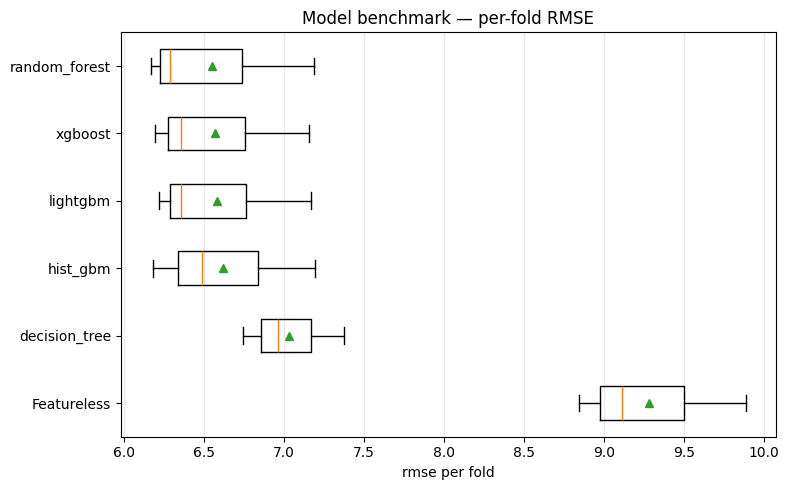

In [10]:
#Finally we print to see the higher performing
from src.model import plot_benchmark

fig, ax = plot_benchmark(benchmark_results)

### Seeing those results, we now select one of the models and train it
This time with more hyperparameters, during a longer period of time, and with a more overall complex resampling strategy.

In [6]:
# Remember to pass a model that handles categorical data, if there will be categorical data in pd version
model_name = "lightgbm"


#model_name = benchmark_results.iloc[0]['model']


model,search = train_final_model(X = x_train,y = y_train,n_iter=40, model_name = model_name,log_target=True) #sample_size to be specified, n_iter

[train_final_model] model=lightgbm  log_target=True  rows=2,150,250  features=18  n_iter=40  cv_splits=3  total_fits=121 (incl. final refit)  scoring=rmsle
[train_final_model] param grid keys: ['regressor__colsample_bytree', 'regressor__learning_rate', 'regressor__max_depth', 'regressor__min_child_samples', 'regressor__n_estimators', 'regressor__num_leaves', 'regressor__reg_alpha', 'regressor__reg_lambda', 'regressor__subsample']

[  1/40] mean_rmsle=0.7655  std=0.0428  folds=['0.790', '0.801', '0.705']  time=391.7s  params={'regressor__subsample': 0.9, 'regressor__reg_lambda': 10.0, 'regressor__reg_alpha': 0.01, 'regressor__num_leaves': 511, 'regressor__n_estimators': 1000, 'regressor__min_child_samples': 5, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.6}
[  2/40] mean_rmsle=0.7799  std=0.0481  folds=['0.808', '0.820', '0.712']  time=221.8s  params={'regressor__subsample': 0.6, 'regressor__reg_lambda': 10.0, 'regressor__reg_alpha': 0.01

In [7]:
print(model)
print(search)

TransformedTargetRegressor(check_inverse=False, func=<ufunc 'log1p'>,
                           inverse_func=<ufunc 'expm1'>,
                           regressor=LGBMRegressor(colsample_bytree=0.7,
                                                   learning_rate=0.01,
                                                   max_depth=8,
                                                   min_child_samples=100,
                                                   n_estimators=200, n_jobs=-2,
                                                   num_leaves=127,
                                                   objective='regression',
                                                   random_state=42, reg_alpha=0,
                                                   reg_lambda=0.1,
                                                   subsample=0.8, verbose=-1))
namespace(best_estimator_=TransformedTargetRegressor(check_inverse=False, func=<ufunc 'log1p'>,
                           inverse_func=<ufunc

In [14]:
evaluate(X = x_train,y = y_train,model=model)

[ 8.65201401 16.24366185 17.20290111 ...  2.83776855  4.69558237
  1.814042  ]
MAE:   5.251
RMSE:  7.065
RMSLE: 0.783


In [9]:
import joblib
# Save the model
joblib.dump(model, f'models/{model_name}v3.joblib')

['models/lightgbmv3.joblib']